In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [ ]:
df = pd.read_csv(fr'data/3D/structure_functions.csv', header=0)
r = np.array(df['r'].tolist())
sp = np.zeros((4, np.size(r)))
sp[0, :] = np.array(df['s2'].tolist())
sp[1, :] = np.array(df['s3'].tolist()) 
sp[2, :] = np.array(df['s4'].tolist()) 
sp[3, :] = np.array(df['s5'].tolist()) 

0.6490071291186951
0.9200734610416139
1.2851276537823024
1.4873664619739637


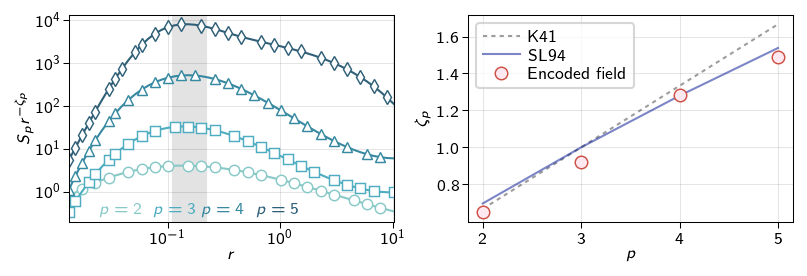

In [ ]:
fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 5.5/2.54 / fig_width
ax_height = 3.5/2.54 / fig_height

from matplotlib.colors import LinearSegmentedColormap, to_hex
cmap_deep = LinearSegmentedColormap.from_list('cmap_deep', ['#231B32', '#3CA4BD', '#F8FFD7'])

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])

def zeta(p):
    return p/9 + 2*(1 - (2/3)**(p/3))

dx = 2*np.pi / 512

from scipy.interpolate import UnivariateSpline

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)

plt.loglog(r*dx, sp_s[0, :]*r**(-zeta(2)), linewidth=1, marker='o', markersize=5, markevery=0.04, markerfacecolor='white', markeredgecolor=to_hex(cmap_deep(0.7)), markeredgewidth=0.7, color=to_hex(cmap_deep(0.7)))
plt.text(2*dx, 0.3, r'$p=2$', color=to_hex(cmap_deep(0.7)))
coeffs = np.polyfit(np.log(r[16:21]), np.log(sp_s[0, 16:21]), 1)
print(coeffs[0])

slope = coeffs[0]
intercept = coeffs[1]

plt.loglog(r*dx, sp_s[1, :]*r**(-zeta(3)), linewidth=1, marker='s', markersize=4.5, markevery=0.04, markerfacecolor='white', markeredgecolor=to_hex(cmap_deep(0.55)), markeredgewidth=0.7, color=to_hex(cmap_deep(0.55)))
plt.text(6*dx, 0.3, r'$p=3$', color=to_hex(cmap_deep(0.55)))
coeffs = np.polyfit(np.log(r[16:21]), np.log(sp_s[1, 16:21]), 1)
print(coeffs[0])

plt.loglog(r*dx, sp_s[2, :]*r**(-zeta(4)), linewidth=1, marker='^', markersize=5, markevery=0.04, markerfacecolor='white', markeredgecolor=to_hex(cmap_deep(0.4)), markeredgewidth=0.7, color=to_hex(cmap_deep(0.4)))
plt.text(16*dx, 0.3, r'$p=4$', color=to_hex(cmap_deep(0.4)))
coeffs = np.polyfit(np.log(r[16:21]), np.log(sp_s[2, 16:21]), 1)
print(coeffs[0])

plt.loglog(r*dx, sp_s[3, :]*r**(-zeta(5)), linewidth=1, marker='d', markersize=5, markevery=0.04, markerfacecolor='white', markeredgecolor=to_hex(cmap_deep(0.25)), markeredgewidth=0.7, color=to_hex(cmap_deep(0.25)))
plt.text(50*dx, 0.3, r'$p=5$', color=to_hex(cmap_deep(0.25)))
coeffs = np.polyfit(np.log(r[16:21]), np.log(sp_s[3, 16:21]), 1)
print(coeffs[0])

plt.axvspan(xmin=9*dx, xmax=18*dx, color='#E3E3E3')

# ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1.2, 0), loc='lower left', fontsize=fontsize-1)
plt.xlim(np.min(r)*dx, np.max(r)*dx) 
# plt.ylim(0, 1)
plt.xlabel(r'$r$', labelpad=0, size=fontsize)
plt.ylabel(r'$S_p r^{-\zeta_p}$', labelpad=1, size=fontsize) # rotation=0
# ax.set_yticks(np.linspace(-1, 1, 3))
# ax.set_yticklabels([r'$10^{-1}$', r'$10^0$', r'$10^1$'])
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=0, width=0.5)


# 
ax = fig.add_axes([ax_width + 0.07, 0, ax_width, ax_height])

p = np.linspace(2, 5, num=4)
zeta_p = [0.6490071291186951, 0.9200734610416139, 1.2851276537823024, 1.4873664619739637]

K41 = p / 3
SL94 = p / 9 + 2 * (1 - (2/3)**(p/3))

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
ax.plot(p, K41, linestyle='--', linewidth=1, dashes=(2, 2), label=r'K41', color="#00000062")
ax.plot(p, SL94, linewidth=1, label=r'SL94', color="#04179485")
ax.plot(p, zeta_p, linestyle='none', marker='o', markersize=6, markevery=(0.03/2, 0.03), markerfacecolor='#FFE9F1', markeredgecolor='#CE5044', markeredgewidth=0.7, label='Encoded field')

ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2.2, handletextpad=0.5, bbox_to_anchor=(0, 1), loc='upper left', fontsize=fontsize)
# plt.xlim(0, 1) 
# plt.ylim(0, 1)
plt.xlabel(r'$p$', labelpad=0, size=fontsize)
plt.ylabel(r'$\zeta_p$', labelpad=3, size=fontsize) # rotation=0
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.set_xticks(np.linspace(2, 5, 4))
ax.set_yticks(np.linspace(0.8, 1.6, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)

# 
plt.savefig(fr'figure.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')